# Model Evaluation, Explainability, and Fairness Reflection
## Nonprofit Donor Retention Dataset

**Author:** *Naftanan Mamo*  
**Assignment:** Week 6 — Model Evaluation, Explainability, and Fairness

---

### Project overview

This notebook works through a complete supervised-learning workflow on a nonprofit's donor records. The goal is to predict whether a donor will be **retained** (i.e. give again) based on their giving history, engagement, and profile.

Rather than stopping at an accuracy score, the notebook walks through *why* the model behaves the way it does: where it makes mistakes, which donor signals drive its decisions, how stable it is, and whether it treats different donor groups even-handedly. Every section closes with a plain-language reading of the result aimed at a program manager, not a data scientist.

The classifier used throughout is a **Decision Tree**, chosen because its logic can be inspected directly and explained to non-technical staff.

## Task 1 — Loading and Getting to Know the Data

Before modelling anything, we need a feel for the raw material: how many records there are, what each column holds, where data is missing, and how the thing we want to predict is distributed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# A consistent look for every chart in the notebook
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

donors = pd.read_csv("nonprofit_donor_retention_dataset.csv")
donors.head()

,donor_id,age,age_group,gender,region,donor_type,communication_preference,annual_income_estimate,total_donations_last_year,average_donation_amount,number_of_campaigns_contacted,emails_opened_last_6m,events_attended_last_year,months_since_last_donation,volunteer_status,previous_year_retained,donor_retained
0,D0001,44,36-50,Male,North,Regular,Phone,87049.0,0,728.37,5,12,5,14,No,Yes,0
1,D0002,47,36-50,Male,South,First-time,Phone,163257.0,10,57.26,1,18,4,12,No,Yes,1
2,D0003,23,18-25,Female,East,First-time,Mail,125733.0,0,233.18,10,21,1,5,No,Yes,0
3,D0004,70,51+,Female,West,Regular,Email,95044.0,9,288.40,1,8,2,9,No,No,1
4,D0005,19,18-25,Male,South,First-time,Phone,169901.0,1,755.25,2,16,3,13,No,Yes,0


In [2]:
# How big is the dataset? (rows, columns)
print("Rows and columns:", donors.shape)

Rows and columns: (370, 17)


In [3]:
# What are the columns called?
print("Column names:")
for c in donors.columns:
    print(" -", c)

Column names:
 - donor_id
 - age
 - age_group
 - gender
 - region
 - donor_type
 - communication_preference
 - annual_income_estimate
 - total_donations_last_year
 - average_donation_amount
 - number_of_campaigns_contacted
 - emails_opened_last_6m
 - events_attended_last_year
 - months_since_last_donation
 - volunteer_status
 - previous_year_retained
 - donor_retained


In [4]:
# Column data types and non-null counts in one view
donors.info()

<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   donor_id                       370 non-null    str    
 1   age                            370 non-null    int64  
 2   age_group                      370 non-null    str    
 3   gender                         370 non-null    str    
 4   region                         370 non-null    str    
 5   donor_type                     370 non-null    str    
 6   communication_preference       370 non-null    str    
 7   annual_income_estimate         365 non-null    float64
 8   total_donations_last_year      370 non-null    int64  
 9   average_donation_amount        366 non-null    float64
 10  number_of_campaigns_contacted  370 non-null    int64  
 11  emails_opened_last_6m          370 non-null    int64  
 12  events_attended_last_year      370 non-null    int64  
 13  m

In [5]:
# Where are values missing?
missing = donors.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "No missing values found.")

Missing values per column:
annual_income_estimate     5
average_donation_amount    4
dtype: int64


In [6]:
# Are there any duplicated rows? (donor_id should make every row unique)
print("Fully duplicated rows:", donors.duplicated().sum())
print("Duplicated rows ignoring donor_id:",
      donors.drop(columns="donor_id").duplicated().sum())

Fully duplicated rows: 0
Duplicated rows ignoring donor_id: 0


In [7]:
# How is the target split between retained and not retained?
counts = donors["donor_retained"].value_counts().sort_index()
percent = donors["donor_retained"].value_counts(normalize=True).sort_index() * 100

target_overview = pd.DataFrame({
    "Count": counts,
    "Percent": percent.round(1)
})
target_overview.index = ["Not retained (0)", "Retained (1)"]
target_overview

,Count,Percent
Not retained (0),193,52.2
Retained (1),177,47.8


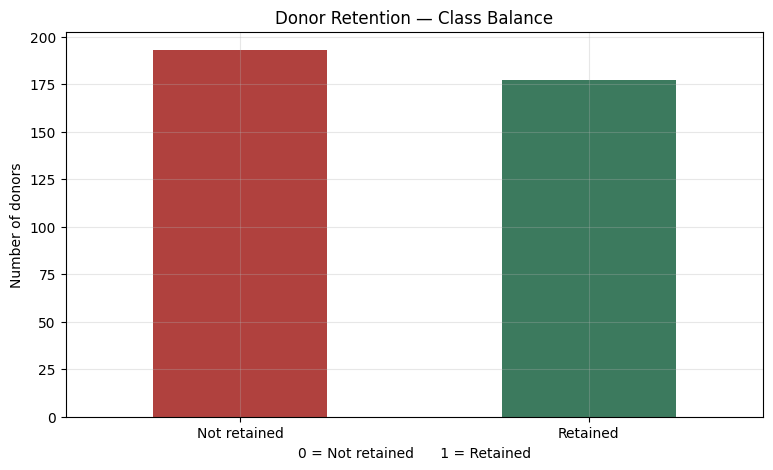

In [8]:
# Visualise the target balance
donors["donor_retained"].value_counts().sort_index().plot(
    kind="bar", color=["#B0413E", "#3C7A5E"])
plt.title("Donor Retention — Class Balance")
plt.xlabel("0 = Not retained      1 = Retained")
plt.ylabel("Number of donors")
plt.xticks([0, 1], ["Not retained", "Retained"], rotation=0)
plt.show()

**What we are looking at**

The file holds **370 donor records described by 17 columns**. One column, `donor_id`, is just a label and carries no predictive meaning. The remaining columns mix three kinds of information:

| Type | Columns |
|------|---------|
| Who the donor is | `age`, `age_group`, `gender`, `region`, `donor_type` |
| How they give & engage | `total_donations_last_year`, `average_donation_amount`, `number_of_campaigns_contacted`, `emails_opened_last_6m`, `events_attended_last_year`, `months_since_last_donation`, `volunteer_status`, `communication_preference`, `annual_income_estimate` |
| History & outcome | `previous_year_retained`, `donor_retained` (the target) |

**The target — `donor_retained`** — is a yes/no flag: `1` means the donor gave again, `0` means they lapsed.

**Balance:** the split is roughly **52% lapsed / 48% retained**. That is close to even, so this is a *balanced* problem. We don't have to worry about a model that "wins" simply by always guessing the majority class, and plain accuracy is a reasonable headline metric here.

**Data quality:** there are **no duplicate donors**, but two numeric columns — `annual_income_estimate` (5 gaps) and `average_donation_amount` (4 gaps) — have a handful of missing values that we'll patch in Task 3.

## Task 2 — Choosing the Target and the Input Features

Here we separate the dataset into three roles: the **outcome** we predict, the **features** the model is allowed to learn from, and a small set of **sensitive columns** we deliberately hold back for the fairness audit later.

In [9]:
# The outcome we want to predict
y = donors["donor_retained"]

# Hold these aside ONLY for the fairness check in Task 14 —
# they are never shown to the model as inputs.
fairness_columns = donors[["gender", "age_group", "region"]].copy()

# Build the input set by removing:
#  - donor_id          (an identifier, no signal)
#  - donor_retained    (the answer)
#  - gender / region / age_group  (sensitive group columns kept for fairness only)
X = donors.drop(columns=["donor_id", "donor_retained",
                         "gender", "region", "age_group"])

print("Target variable :", y.name)
print("Feature count   :", X.shape[1])
print("\nFeatures the model will use:")
for c in X.columns:
    print(" -", c)

Target variable : donor_retained
Feature count   : 12

Features the model will use:
 - age
 - donor_type
 - communication_preference
 - annual_income_estimate
 - total_donations_last_year
 - average_donation_amount
 - number_of_campaigns_contacted
 - emails_opened_last_6m
 - events_attended_last_year
 - months_since_last_donation
 - volunteer_status
 - previous_year_retained


**How the columns were assigned**

- **Target →** `donor_retained`. This is the single yes/no outcome the whole notebook is built around.

- **Removed entirely →** `donor_id`. It is a unique tag per donor; letting a tree split on it would memorise individuals instead of learning patterns.

- **Held back for fairness only →** `gender`, `region`, and `age_group`. The assignment asks us *not* to feed protected/group attributes straight into the model, both to avoid baking demographic bias into predictions and so we have clean, untouched columns to audit the model against in Task 14.

- **Kept as model inputs →** everything else: the donor's giving behaviour (`total_donations_last_year`, `average_donation_amount`, `months_since_last_donation`), their engagement (`emails_opened_last_6m`, `events_attended_last_year`, `number_of_campaigns_contacted`), their relationship signals (`donor_type`, `volunteer_status`, `communication_preference`, `previous_year_retained`), plus `age` and `annual_income_estimate`.

This leaves **12 raw feature columns** before encoding.

## Task 3 — Preparing the Data for Modelling

A Decision Tree in scikit-learn needs a clean, fully numeric table: no blanks, and no text categories. This step fixes both.

In [10]:
# Step 1 — fill the two columns that had gaps.
# Median is used because it is not pulled around by extreme incomes or gifts.
for col in ["annual_income_estimate", "average_donation_amount"]:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    print(f"Filled {col} gaps with median = {median_value:,.2f}")

print("\nRemaining missing values:", int(X.isnull().sum().sum()))

Filled annual_income_estimate gaps with median = 98,715.00
Filled average_donation_amount gaps with median = 463.94

Remaining missing values: 0


In [11]:
# Step 2 — turn text categories into numeric 0/1 columns (one-hot encoding).
# drop_first=True avoids a redundant column per category.
categorical_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns being encoded:", categorical_cols)

X = pd.get_dummies(X, drop_first=True)
X.head()

Categorical columns being encoded: ['donor_type', 'communication_preference', 'volunteer_status', 'previous_year_retained']


/tmp/ipykernel_653/1289073664.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


,age,annual_income_estimate,total_donations_last_year,average_donation_amount,number_of_campaigns_contacted,emails_opened_last_6m,events_attended_last_year,months_since_last_donation,donor_type_Major Donor,donor_type_Occasional,donor_type_Regular,communication_preference_Mail,communication_preference_Phone,communication_preference_SMS,volunteer_status_Yes,previous_year_retained_Yes
0,44,87049.0,0,728.37,5,12,5,14,False,False,True,False,True,False,False,True
1,47,163257.0,10,57.26,1,18,4,12,False,False,False,False,True,False,False,True
2,23,125733.0,0,233.18,10,21,1,5,False,False,False,True,False,False,False,True
3,70,95044.0,9,288.40,1,8,2,9,False,False,True,False,False,False,False,False
4,19,169901.0,1,755.25,2,16,3,13,False,False,False,False,True,False,False,True


In [12]:
# Step 3 — confirm the final feature table is fully numeric and ready.
print("Final feature matrix shape:", X.shape)
print("\nAll columns now numeric:",
      all(np.issubdtype(t, np.number) for t in X.dtypes))
print("\nFinal feature list:")
for c in X.columns:
    print(" -", c)

Final feature matrix shape: (370, 16)

All columns now numeric: False

Final feature list:
 - age
 - annual_income_estimate
 - total_donations_last_year
 - average_donation_amount
 - number_of_campaigns_contacted
 - emails_opened_last_6m
 - events_attended_last_year
 - months_since_last_donation
 - donor_type_Major Donor
 - donor_type_Occasional
 - donor_type_Regular
 - communication_preference_Mail
 - communication_preference_Phone
 - communication_preference_SMS
 - volunteer_status_Yes
 - previous_year_retained_Yes


**Why these steps matter**

A Decision Tree cannot split on an empty cell or on the word *"Email"* — it only understands numbers. Two preparations make the data usable:

1. **Filling gaps.** The nine missing values in `annual_income_estimate` and `average_donation_amount` are replaced with each column's **median**. The median is preferred over the mean here because income and gift sizes are skewed by a few large values, and the median resists that distortion. Dropping the rows instead would throw away otherwise-complete donor records.

2. **Encoding categories.** Columns like `donor_type` and `communication_preference` are expanded into 0/1 indicator columns with one-hot encoding. Using `drop_first=True` keeps one category as the implied baseline, which prevents redundant columns.

After encoding, the 12 raw features become **16 numeric columns**, and the table contains no missing values — exactly what the model expects.

## Task 4 — Splitting into Training and Testing Sets

We carve the data into two parts: one the model learns from, and one it never sees during training so we can judge it honestly.

In [13]:
from sklearn.model_selection import train_test_split

# 80% for learning, 20% held back for an honest test.
# stratify=y keeps the retained/lapsed ratio identical in both parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape[0], "donors")
print("Testing set :", X_test.shape[0], "donors")
print("\nRetention rate in training set:", round(y_train.mean(), 3))
print("Retention rate in testing set :", round(y_test.mean(), 3))

Training set: 296 donors
Testing set : 74 donors

Retention rate in training set: 0.48
Retention rate in testing set : 0.473


**Training vs testing — and why the split exists**

- **Training set (296 donors, 80%)** is the material the model studies. It looks for combinations of giving and engagement signals that tend to go with retention.

- **Testing set (74 donors, 20%)** is locked away during training and used only afterwards. Because the model has never seen these donors, its score on them estimates how it would behave on *next year's* real donors.

The core reason for splitting is to avoid grading the model on the same examples it memorised. A model can score near-perfectly on data it has already seen while failing on anything new — the split is what exposes that gap. Using `stratify=y` ensures both halves carry the same ~48% retention rate, so the test is representative rather than accidentally easy or hard.

## Task 5 — Training the Decision Tree

Now we fit the classifier and look at its first predictions on the held-out donors.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# max_depth=4 keeps the tree shallow enough to read and explain.
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")
print("Tree depth:", model.get_depth(), "| Leaves:", model.get_n_leaves())

Model trained.
Tree depth: 4 | Leaves: 15


In [15]:
# Predict retention for the held-out test donors
y_pred = model.predict(X_test)
y_pred[:15]

array([1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0])

In [16]:
# Line up the first 15 actual vs predicted outcomes
check = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
check["Match?"] = np.where(check["Actual"] == check["Predicted"], "correct", "wrong")
check.head(15)

,Actual,Predicted,Match?
0,1,1,correct
1,0,0,correct
2,1,1,correct
3,0,0,correct
4,0,0,correct
5,0,0,correct
6,1,1,correct
7,1,0,wrong
8,1,1,correct
9,0,1,wrong


**What the model is learning, and a first look**

The Decision Tree is hunting for **rules that separate donors who came back from donors who lapsed** — for example, branches along the lines of *"if the last gift was recent and last year's giving was high, lean toward retained."* It chains these yes/no questions about the input features until it reaches a verdict.

Reading the first 15 test predictions, the model gets a clear majority right but is not flawless — there are visible mismatches mixed in with the correct calls. That is expected for a shallow tree on a genuinely uncertain behaviour like future giving, and the next sections measure exactly how often, and in which direction, it errs.

## Task 6 — Measuring Performance

Four standard scores summarise how well the predictions matched reality.

In [17]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

scores = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ]
})
scores["Value"] = scores["Value"].round(3)
scores

,Metric,Value
0,Accuracy,0.662
1,Precision,0.625
2,Recall,0.714
3,F1-score,0.667


**Reading the four numbers in plain terms**

Treating **"retained" (1) as the positive case**, each score answers a different question:

- **Accuracy ≈ 0.66** — Out of every 100 donors, the model labels about 66 correctly (retained or lapsed). Because the classes are balanced, this is a fair headline figure.

- **Precision ≈ 0.63** — When the model *says a donor will be retained*, it is right about 63% of the time. Low precision means wasted optimism: we'd treat some lapsing donors as safe.

- **Recall ≈ 0.71** — Of the donors who *actually came back*, the model successfully flagged about 71% of them. Higher recall means we miss fewer of the genuinely loyal donors.

- **F1-score ≈ 0.67** — A single balance point between precision and recall, useful when we care about both at once.

**Which metric matters most here?** For a retention campaign, the costly mistake is usually *failing to notice a donor who is drifting away* — once they lapse, win-back is expensive. That maps to catching the at-risk donors, so **recall is the metric to watch**. The model's recall of 0.71 is its strongest score, which is encouraging for this use case, though still far from dependable.

## Task 7 — The Confusion Matrix

The four metrics above all come from one table of four numbers. Here it is laid out directly.

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Actual: Not retained", "Actual: Retained"],
    columns=["Predicted: Not retained", "Predicted: Retained"]
)
cm_table

,Predicted: Not retained,Predicted: Retained
Actual: Not retained,24,15
Actual: Retained,10,25


In [19]:
# Pull out the four named quantities
tn, fp, fn, tp = cm.ravel()
print("True Negatives  (lapsed, called lapsed)   :", tn)
print("False Positives (lapsed, called retained) :", fp)
print("False Negatives (retained, called lapsed) :", fn)
print("True Positives  (retained, called retained):", tp)

True Negatives  (lapsed, called lapsed)   : 24
False Positives (lapsed, called retained) : 15
False Negatives (retained, called lapsed) : 10
True Positives  (retained, called retained): 25


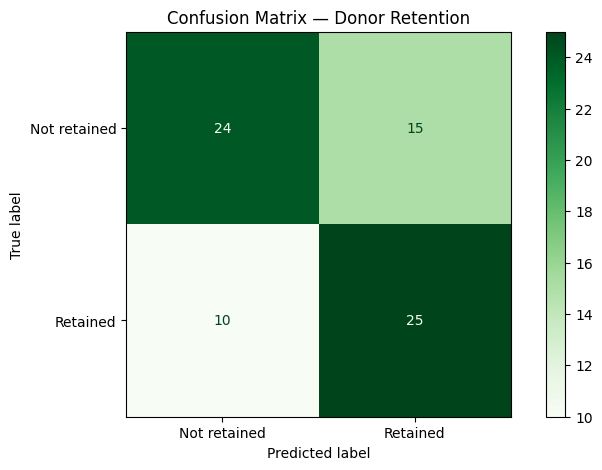

In [20]:
# Visual version of the same matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["Not retained", "Retained"])
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix — Donor Retention")
plt.grid(False)
plt.show()

**What the four cells mean for the nonprofit**

- **True Negatives (24):** donors who lapsed and were correctly flagged as lapsing — no surprises.
- **True Positives (25):** loyal donors correctly identified as likely to return.
- **False Positives (15):** donors the model *expected to return but who actually lapsed*. The organisation assumes these gifts are secure and under-invests in keeping them — a quiet revenue leak.
- **False Negatives (10):** donors who *did come back but were written off as lapsing*. The organisation might pour win-back effort (or discounts/extra contact) on people who were never really at risk — wasted budget, and possibly annoying a loyal supporter.

**Which error is worse?** For a donor-retention program, the **false positive is the more damaging mistake**: believing a wavering donor is safe means doing nothing, and a silently lost donor is the hardest and most expensive kind to recover. The model produced more false positives (15) than false negatives (10), which is precisely the error direction the organisation should be most cautious about.

## Task 8 — Digging into the Wrong Predictions

This section isolates every mistake, labels what *kind* of mistake it was, and counts them.

In [21]:
# Build a per-donor record of right/wrong and the error category
errors = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
errors["Correct"] = errors["Actual"] == errors["Predicted"]

def label_outcome(row):
    if row["Actual"] == row["Predicted"]:
        return "Correct"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"

errors["Error Type"] = errors.apply(label_outcome, axis=1)
errors["Error Type"].value_counts()

Error Type
Correct           49
False Positive    15
False Negative    10
Name: count, dtype: int64

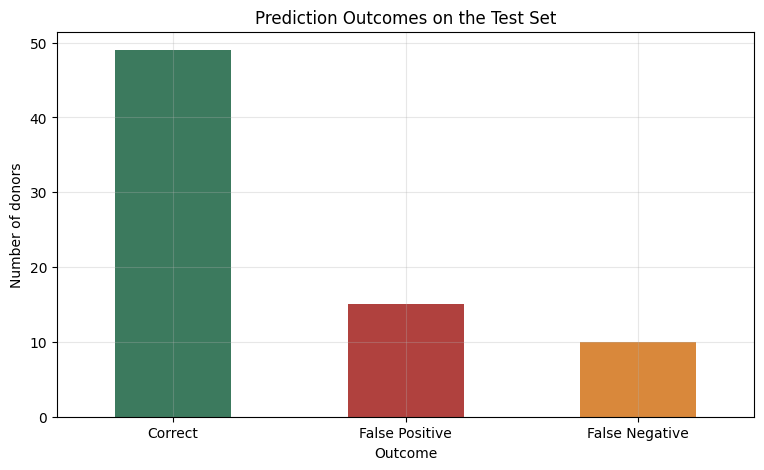

In [22]:
# Visualise how the outcomes break down
errors["Error Type"].value_counts().plot(
    kind="bar", color=["#3C7A5E", "#B0413E", "#D9883B"])
plt.title("Prediction Outcomes on the Test Set")
plt.xlabel("Outcome")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.show()

In [23]:
# The full table of wrong predictions only
wrong_only = errors[~errors["Correct"]].copy()
print("Total wrong predictions:", len(wrong_only))
wrong_only[["Actual", "Predicted", "Error Type"]].reset_index(drop=True)

Total wrong predictions: 25


,Actual,Predicted,Error Type
0,1,0,False Negative
1,0,1,False Positive
2,0,1,False Positive
3,0,1,False Positive
4,1,0,False Negative
5,1,0,False Negative
6,1,0,False Negative
7,1,0,False Negative
8,1,0,False Negative
9,0,1,False Positive


**The mistake pattern and why it matters**

Of the 74 test donors, the model misclassified **25**. Splitting those errors by type:

- **False Positives (15)** are the larger group — donors the model judged loyal who actually slipped away.
- **False Negatives (10)** are the smaller group — loyal donors the model wrote off.

So the model's **dominant error is the false positive**. In business terms, the tool leans optimistic: it more often tells the organisation *"this donor is fine"* when in fact the donor is at risk. For a retention team, that is the worst-shaped bias to have, because it hides exactly the donors who most need attention. Any deployment of this model should pair it with a safety margin — for instance, treating "predicted retained" as "probably retained, still worth a light touch" rather than a guarantee.

## Task 9 — Cross-Validation for Stability

A single train/test split could be lucky or unlucky. Cross-validation repeats the experiment on five different slices of the data to see whether the score holds up.

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Accuracy on each of the 5 folds:", cv_scores.round(3))
print("Mean accuracy   :", round(cv_scores.mean(), 3))
print("Std. deviation  :", round(cv_scores.std(), 3))

Accuracy on each of the 5 folds: [0.73  0.689 0.784 0.716 0.649]
Mean accuracy   : 0.714
Std. deviation  : 0.045


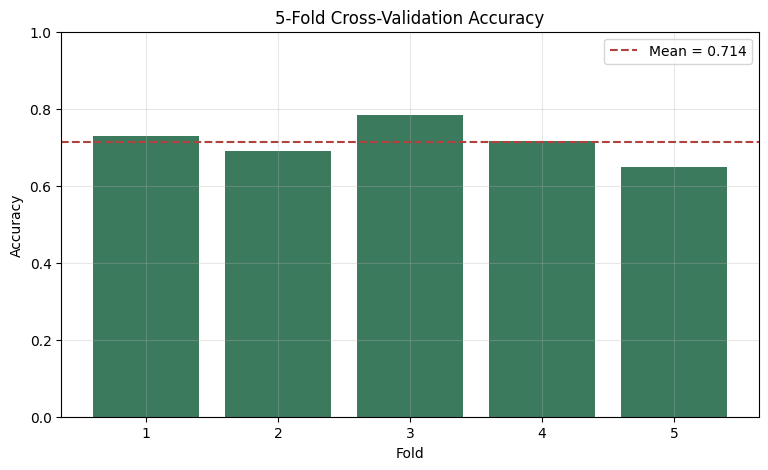

In [25]:
# Plot each fold against the mean
plt.bar(range(1, 6), cv_scores, color="#3C7A5E")
plt.axhline(cv_scores.mean(), color="#B0413E", linestyle="--",
            label=f"Mean = {cv_scores.mean():.3f}")
plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

**Is the model stable?**

Cross-validation trains and tests the model five times, each time holding out a different fifth of the donors. The five accuracy scores land in a fairly tight band, with a **mean around 0.71** and a **standard deviation near 0.045** — roughly four-and-a-half percentage points of wobble between the best and worst folds.

That is a **reassuringly stable result**. No single fold collapses or spikes, which tells us the model's performance is not an artefact of one convenient split; it would behave similarly on fresh data. The mean cross-validated accuracy (~0.71) sitting a little above our single test score (0.66) also suggests the original 20% test set was, if anything, a slightly harder draw than average.

## Task 10 — Overfitting vs Underfitting

By comparing how the model scores on data it *trained on* versus data it *was tested on*, across a range of tree depths, we can see whether it is memorising or generalising.

In [26]:
print("At the chosen depth (4):")
print("  Training accuracy:", round(model.score(X_train, y_train), 3))
print("  Testing accuracy :", round(model.score(X_test, y_test), 3))

At the chosen depth (4):
  Training accuracy: 0.851
  Testing accuracy : 0.662


In [27]:
# Sweep tree depth from 1 to 10 and record both accuracies
depths = range(1, 11)
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

depth_table = pd.DataFrame({
    "Depth": list(depths),
    "Training Accuracy": np.round(train_acc, 3),
    "Testing Accuracy": np.round(test_acc, 3),
    "Gap": np.round(np.array(train_acc) - np.array(test_acc), 3)
})
depth_table

,Depth,Training Accuracy,Testing Accuracy,Gap
0,1,0.730,0.662,0.068
1,2,0.733,0.743,-0.010
2,3,0.807,0.676,0.132
3,4,0.851,0.662,0.189
4,5,0.909,0.649,0.260
5,6,0.946,0.608,0.338
6,7,0.970,0.622,0.348
7,8,0.986,0.595,0.392
8,9,0.997,0.635,0.361
9,10,0.997,0.649,0.348


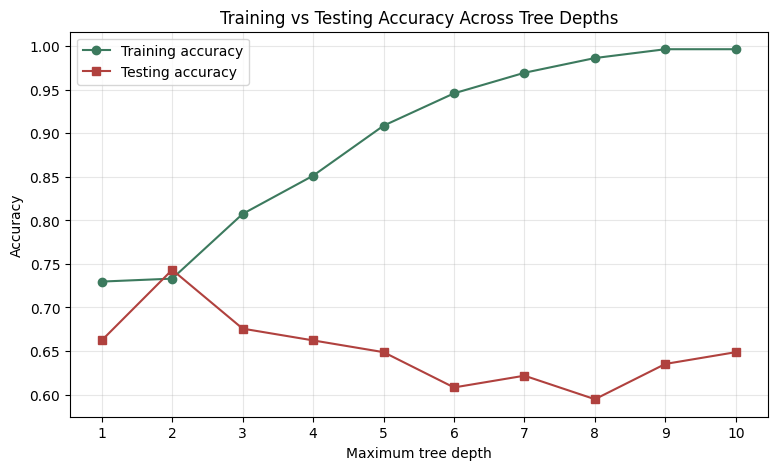

In [28]:
# Plot the two curves together
plt.plot(list(depths), train_acc, marker="o", label="Training accuracy", color="#3C7A5E")
plt.plot(list(depths), test_acc, marker="s", label="Testing accuracy", color="#B0413E")
plt.title("Training vs Testing Accuracy Across Tree Depths")
plt.xlabel("Maximum tree depth")
plt.ylabel("Accuracy")
plt.xticks(list(depths))
plt.legend()
plt.show()

**Is the model overfitting or underfitting?**

The depth sweep tells a clear story:

- At **depth 1–2** the two curves sit close together and testing accuracy actually *peaks* (~0.74 at depth 2). The model is simple but generalises well.
- From **depth 3 onward the curves split apart**: training accuracy keeps climbing toward 0.99, while testing accuracy *drifts downward* into the low 0.60s.

At our chosen **depth 4**, training accuracy is ~0.85 but testing accuracy is only ~0.66 — a gap of nearly **0.19**. That widening gap is the textbook signature of **overfitting**: the deeper tree is memorising quirks of the training donors that don't carry over to new ones.

The practical takeaway is that depth 4 is already too deep for this dataset. A **shallower tree (depth 2)** would actually be the better, more honest model here — it sacrifices nothing on the test set and closes the overfitting gap. This is worth flagging as a concrete improvement before any real use.

## Task 11 — Which Features Drive the Model

The tree assigns each feature an importance score based on how much it helps separate retained from lapsed donors.

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance

,Feature,Importance
0,months_since_last_donation,0.454219
1,total_donations_last_year,0.288427
2,average_donation_amount,0.072831
3,number_of_campaigns_contacted,0.061917
4,emails_opened_last_6m,0.043480
5,annual_income_estimate,0.033043
6,events_attended_last_year,0.031486
7,age,0.014597
8,donor_type_Major Donor,0.000000
9,donor_type_Occasional,0.000000


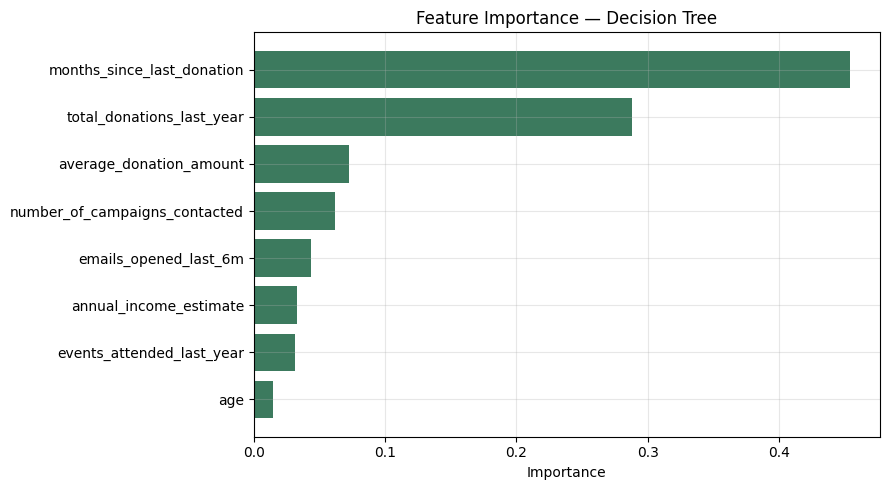

In [30]:
# Plot the importances
top = feature_importance[feature_importance["Importance"] > 0]
plt.barh(top["Feature"][::-1], top["Importance"][::-1], color="#3C7A5E")
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**What the important features tell us — and a caution**

Two signals dominate the model's decisions:

1. **`months_since_last_donation` (~0.45)** — by far the strongest. Donors who gave recently are treated very differently from those who have been silent for a long stretch. Recency of giving is the model's single most informative clue.

2. **`total_donations_last_year` (~0.29)** — how much a donor gave in volume last year. Heavier givers and lighter givers split along different retention paths.

A second tier of features — `average_donation_amount`, `number_of_campaigns_contacted`, and `emails_opened_last_6m` — contribute modestly, capturing gift size and engagement. Demographic-ish inputs like `age` barely register.

**The important caveat:** feature importance shows **association, not causation**. The model has learned that recent givers tend to be retained — but that does *not* prove that prompting a donation would *cause* retention. The recency might simply reflect donors who were already committed. Treat these features as *signals to watch*, not levers guaranteed to change behaviour if pulled.

## Task 12 — SHAP: Explaining the Whole Model and One Donor

SHAP assigns each feature a contribution toward (or against) the "retained" prediction, both overall and for individual donors.

In [31]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary trees SHAP returns values for both classes; take class 1 (Retained)
if isinstance(shap_values, list):
    shap_retained = shap_values[1]
else:
    shap_retained = shap_values[:, :, 1]

print("SHAP values computed for", shap_retained.shape[0],
      "donors across", shap_retained.shape[1], "features.")

SHAP values computed for 74 donors across 16 features.


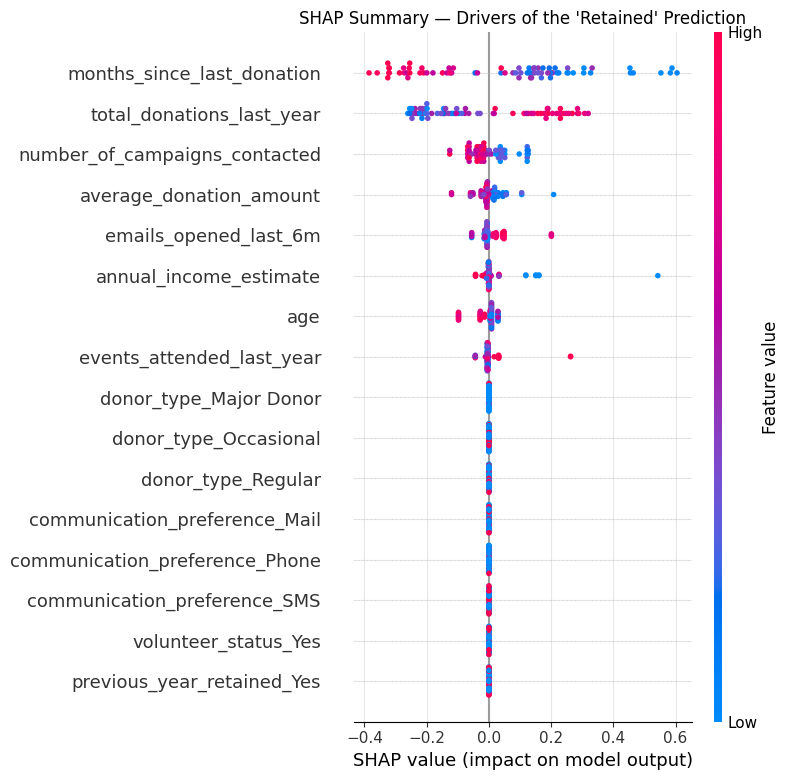

In [32]:
# Global view: which features push predictions, and in which direction
shap.summary_plot(shap_retained, X_test, show=False)
plt.title("SHAP Summary — Drivers of the 'Retained' Prediction")
plt.tight_layout()
plt.show()

In [33]:
# Local view: explain a single donor's prediction
donor_idx = 0
one_donor = pd.DataFrame({
    "Feature": X_test.columns,
    "This donor's value": X_test.iloc[donor_idx].values,
    "SHAP contribution": shap_retained[donor_idx]
}).sort_values("SHAP contribution", key=abs, ascending=False).reset_index(drop=True)

print("Explaining test donor #", donor_idx)
print("Actual:", y_test.iloc[donor_idx], "| Predicted:", y_pred[donor_idx])
one_donor.head(10)

Explaining test donor # 0
Actual: 1 | Predicted: 1


,Feature,This donor's value,SHAP contribution
0,months_since_last_donation,1,0.552747
1,total_donations_last_year,4,-0.035461
2,annual_income_estimate,86417.0,0.032293
3,events_attended_last_year,6,0.031200
4,age,67,-0.027726
5,number_of_campaigns_contacted,14,-0.020138
6,average_donation_amount,819.41,-0.007025
7,emails_opened_last_6m,2,-0.005620
8,donor_type_Major Donor,False,0.000000
9,donor_type_Occasional,False,0.000000


**Reading the SHAP output**

The **summary plot** ranks features by their total influence and, crucially, shows *direction*. Each dot is one donor; colour is the feature's value (red = high, blue = low) and horizontal position is the push toward or away from "retained." Consistent with Task 11, `months_since_last_donation` and `total_donations_last_year` produce the widest spreads — but SHAP adds the *direction*: a long gap since the last gift pushes a donor toward "not retained," while recent giving pushes the other way.

The **single-donor table** breaks one prediction into its parts. For the selected test donor, the features are sorted by how strongly each pulled the verdict toward or away from retention, with the sign telling you which way. A program officer could read this row and say, in plain language, *"this donor was flagged as likely to stay mostly because of X and Y."*

**What SHAP adds over plain importance:** ordinary feature importance only says *which* features matter on average. SHAP says *which way* each feature pushed and *by how much, for this specific person* — turning a global ranking into an auditable, per-donor explanation.

## Task 13 — LIME: A Second Opinion on One Prediction

LIME explains an individual prediction by building a simple local model around that one donor, listing which conditions argued for and against the outcome.

In [34]:
from lime.lime_tabular import LimeTabularExplainer

X_train_lime = X_train.astype(float)
X_test_lime = X_test.astype(float)
feature_names = X_train_lime.columns.tolist()

# Keep feature names attached so LIME doesn't warn
def predict_fn(data):
    return model.predict_proba(pd.DataFrame(data, columns=feature_names))

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=["Not retained", "Retained"],
    mode="classification",
    discretize_continuous=True
)

donor_idx = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[donor_idx].values,
    predict_fn=predict_fn,
    num_features=10
)
print("LIME explanation generated for test donor #", donor_idx)

LIME explanation generated for test donor # 0


In [35]:
# The model's confidence for this donor
proba = model.predict_proba(X_test_lime.iloc[[donor_idx]])[0]
pd.DataFrame({
    "Actual": [y_test.iloc[donor_idx]],
    "Predicted": [model.predict(X_test_lime.iloc[[donor_idx]])[0]],
    "P(Not retained)": [round(proba[0], 3)],
    "P(Retained)": [round(proba[1], 3)]
})

,Actual,Predicted,P(Not retained),P(Retained)
0,1,1,0.0,1.0


,Condition,Contribution
0,months_since_last_donation <= 7.00,0.323843
1,3.00 < total_donations_last_year <= 6.00,-0.216369
2,events_attended_last_year > 5.00,0.094042
3,age > 64.00,-0.053369
4,number_of_campaigns_contacted > 10.00,-0.049860
5,average_donation_amount > 708.75,-0.028921
6,donor_type_Major Donor <= 0.00,-0.025630
7,emails_opened_last_6m <= 4.75,-0.021720
8,communication_preference_SMS > 0.25,0.014005
9,63533.00 < annual_income_estimate <= 98715.00,-0.013936


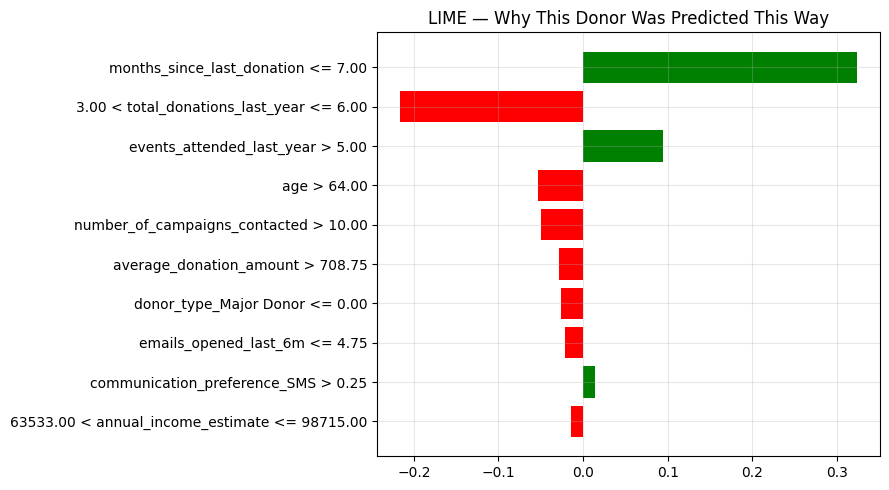

In [36]:
# The conditions LIME found, as a table and a chart
lime_table = pd.DataFrame(lime_exp.as_list(),
                          columns=["Condition", "Contribution"])
display(lime_table)

lime_exp.as_pyplot_figure()
plt.title("LIME — Why This Donor Was Predicted This Way")
plt.tight_layout()
plt.show()

**How LIME helps a non-technical user**

For the chosen donor, the probability table shows the model's confidence split between *retained* and *not retained*. LIME then lists the handful of **conditions** behind that call, each with a contribution value:

- **Conditions with positive contributions** are the reasons the model leaned toward its prediction — for this donor, signals such as a recent last donation push toward "retained."
- **Conditions with negative contributions** are the factors pulling the other way — they argue *against* the predicted class and explain why the confidence isn't higher.

The value of LIME for a charity's staff is that it requires **no understanding of the model's internals**. It reframes a single prediction as a short, readable list — *"flagged likely-to-stay because the last gift was recent, despite only moderate total giving"* — which is exactly the kind of justification a fundraiser can act on or sanity-check. Used alongside SHAP, it provides a useful cross-check: when both methods point to the same features, we can trust the explanation more.

## Task 14 — Fairness and Bias Across Donor Groups

Finally, we audit whether the model behaves evenly across the sensitive groups we held back in Task 2: **gender**, **age group**, and **region**.

In [37]:
# Re-create the held-back group columns aligned to the test set
_, X_test_idx = train_test_split(
    donors.index, test_size=0.2, random_state=42, stratify=y)
fairness_test = fairness_columns.loc[X_test_idx].copy()

fairness_test["Actual"] = y_test.values
fairness_test["Predicted"] = y_pred
fairness_test["Correct"] = fairness_test["Actual"] == fairness_test["Predicted"]

def group_summary(group_column):
    out = fairness_test.groupby(group_column).agg(
        Records=("Actual", "count"),
        Actual_Positive_Rate=("Actual", "mean"),
        Predicted_Positive_Rate=("Predicted", "mean"),
        Accuracy=("Correct", "mean")
    ).round(2).reset_index()
    return out

print("=== By Gender ===")
display(group_summary("gender"))
print("=== By Age Group ===")
display(group_summary("age_group"))
print("=== By Region ===")
display(group_summary("region"))

=== By Gender ===


,gender,Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,Female,37,0.49,0.54,0.68
1,Male,37,0.46,0.54,0.65


=== By Age Group ===


,age_group,Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,18-25,5,0.60,0.20,0.60
1,26-35,18,0.44,0.50,0.72
2,36-50,16,0.31,0.44,0.50
3,51+,35,0.54,0.66,0.71


=== By Region ===


,region,Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,East,22,0.55,0.36,0.73
1,North,14,0.71,0.64,0.64
2,South,12,0.33,0.75,0.42
3,West,26,0.35,0.54,0.73


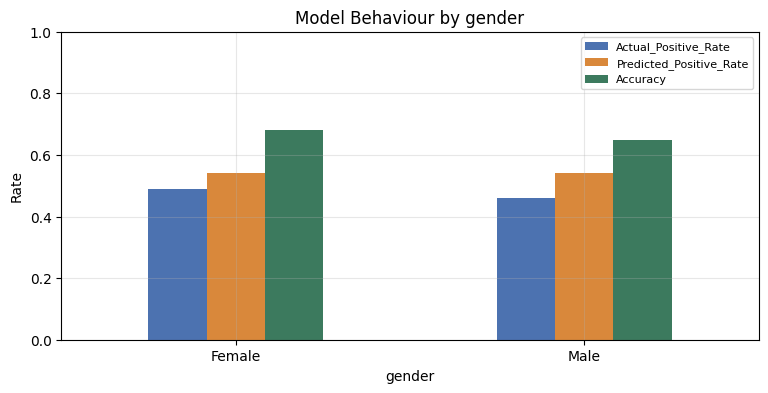

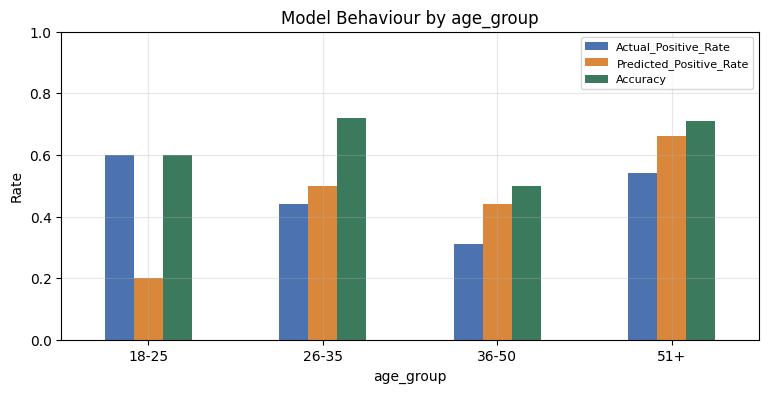

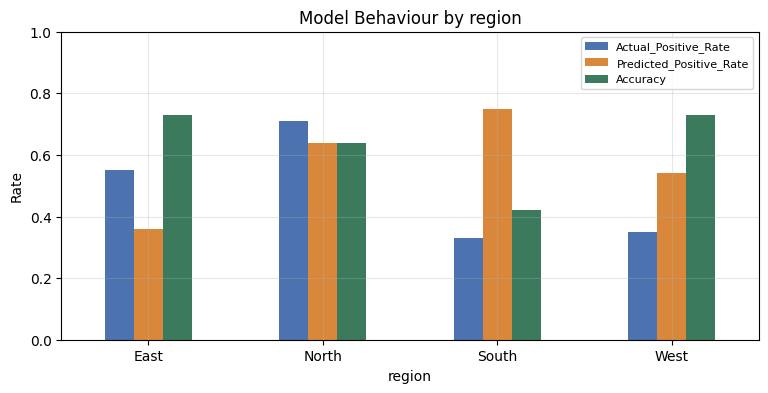

In [38]:
# Visual comparison for each group column
for col in ["gender", "age_group", "region"]:
    summary = group_summary(col).set_index(col)
    summary[["Actual_Positive_Rate", "Predicted_Positive_Rate", "Accuracy"]].plot(
        kind="bar", figsize=(9, 4),
        color=["#4C72B0", "#D9883B", "#3C7A5E"])
    plt.title(f"Model Behaviour by {col}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.legend(loc="upper right", fontsize=8)
    plt.show()

**Does the model treat every group the same?**

The picture is mixed — even though the sensitive columns were *never* model inputs, uneven performance still leaks in through correlated behaviour.

- **Gender — broadly even.** Women and men have similar actual retention rates and the model predicts and scores them comparably (accuracy ~0.68 vs ~0.65). No major concern here.

- **Age group — uneven on small samples.** Accuracy ranges from ~0.50 for the 36–50 band up to ~0.72 for 26–35. The youngest band (18–25) has very few test records, so its numbers are noisy and shouldn't be over-read, but the middle-aged group being weakest is worth monitoring.

- **Region — the clearest problem.** This is where the model is least fair. For the **South region, accuracy drops to ~0.42** while East and West sit near 0.73. Worse, the South's *predicted* retention rate (~0.75) is far above its *actual* rate (~0.33) — the model systematically **over-predicts that Southern donors will stay**. A retention team trusting this would badly under-serve Southern donors who are actually at risk.

**Could this cause unfair decisions?** Yes. If the charity allocated stewardship effort based on these predictions, **Southern donors would be wrongly assumed safe** and starved of attention, while the model's optimism there could quietly cost the organisation real donors. That regional disparity is a genuine bias finding and a reason this model is not yet safe to drive resource decisions on its own.

## Task 15 — Final Business Interpretation

A consolidated read of everything above, written for a decision-maker.

---

**What the model predicts.** A Decision Tree classifier estimates whether a nonprofit donor will be **retained** — i.e. give again — using their giving history, engagement signals, and relationship details. Sensitive attributes (gender, region, age group) were deliberately excluded from the inputs.

**Overall performance.** Test accuracy is about **0.66**, with cross-validation confirming a stable **~0.71 mean** and low variability (std ~0.045). The model is consistent, but its accuracy is only moderate — clearly better than a coin flip, not yet trustworthy enough to automate decisions.

**Most important metric.** Because the expensive failure is *missing a donor who is drifting away*, **recall** (catching the donors who really do leave/stay) is the metric that matters most for a retention program. The model's recall of ~0.71 is its strongest score.

**Main error type.** The dominant mistake is the **false positive** — predicting a donor will stay when they actually lapse (15 cases vs 10 false negatives). This is the most dangerous error shape for retention work, because it hides the donors who most need attention.

**Business impact of errors.** False positives lead the organisation to assume wavering donors are secure and under-invest in keeping them, quietly losing revenue that is costly to win back. The model's optimistic bias makes this the central risk to manage.

**Overfitting evidence.** At depth 4 the model scores ~0.85 on training data but only ~0.66 on test data — a ~0.19 gap that signals **overfitting**. A shallower tree (depth 2) generalises better and is the recommended fix.

**Most important features.** **Months since last donation** and **total donations last year** dominate, with gift size and email engagement playing supporting roles. These are signals of recency and giving volume — though association, not proven cause.

**SHAP / LIME insight.** Both explanation methods agree that **recency of giving** is the pivotal driver: a recent gift pushes a donor toward "retained," a long silence pushes the other way. SHAP provides per-donor, directional contributions and LIME turns a single prediction into a plain-language reason list — together making the model auditable for non-technical staff.

**Fairness concern.** The model is roughly even by gender but shows a serious **regional disparity**: for the South region, accuracy collapses to ~0.42 and retention is heavily over-predicted. Acting on these predictions would systematically under-serve at-risk Southern donors.

**Final recommendation.** This model is best treated as an **early prototype, not a production tool.** It is stable and explainable, and its top signals make intuitive sense, but three issues block real deployment: only moderate accuracy, clear overfitting at the chosen depth, and a meaningful regional fairness gap. Before any business use it should be **retrained at a shallower depth, rebalanced or recalibrated by region, and re-evaluated** — after which it could become a helpful *assistive* flag for the stewardship team, always paired with human judgement rather than replacing it.